In [1]:
# ============================================
# JUNE 3: Cross-Validation + Bias-Variance Tradeoff
# ============================================

# Step 1: Import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.datasets import load_iris, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

### What this does:

- Imports all necessary libraries for machine learning

- Sets a random seed (42) so results are reproducible

- Uses seaborn style for nicer-looking plots

In [2]:
# ============================================
# PART 1: CROSS-VALIDATION COMPARISON (cv=5 vs cv=10)
# ============================================

print("="*60)
print("PART 1: CROSS-VALIDATION COMPARISON (cv=5 vs cv=10)")
print("="*60)

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Create Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform cross-validation with cv=5
scores_5 = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
scores_10 = cross_val_score(rf, X, y, cv=10, scoring='accuracy')

print("\n📊 Cross-Validation Results:")
print("-" * 40)
print(f"cv=5  → Mean: {scores_5.mean():.4f} ± {scores_5.std():.4f}")
print(f"cv=10 → Mean: {scores_10.mean():.4f} ± {scores_10.std():.4f}")

PART 1: CROSS-VALIDATION COMPARISON (cv=5 vs cv=10)

📊 Cross-Validation Results:
----------------------------------------
cv=5  → Mean: 0.9667 ± 0.0211
cv=10 → Mean: 0.9600 ± 0.0327


### What this does:

- Loads the classic Iris dataset (150 samples, 3 flower species)

- Creates a Random Forest model with 100 trees

- cv=5: Splits data into 5 folds → uses 80% for training, 20% for testing each time

- cv=10: Splits data into 10 folds → uses 90% for training, 10% for testing each time

Key insight: cv=10 uses more training data but has smaller test sets, which can lead to more variable scores.

In [3]:
print("\n📈 Individual Fold Scores:")
print(f"cv=5 folds:  {[f'{s:.4f}' for s in scores_5]}")
print(f"cv=10 folds: {[f'{s:.4f}' for s in scores_10]}")

# Interpretation
print("\n💡 Interpretation:")
if scores_10.std() > scores_5.std():
    print("   → cv=10 has HIGHER variance (more fluctuation between folds)")
    print("   → Smaller test sets (10% each) cause more instability")
else:
    print("   → cv=5 has higher variance")


📈 Individual Fold Scores:
cv=5 folds:  ['0.9667', '0.9667', '0.9333', '0.9667', '1.0000']
cv=10 folds: ['1.0000', '0.9333', '1.0000', '0.9333', '0.9333', '0.9333', '0.9333', '0.9333', '1.0000', '1.0000']

💡 Interpretation:
   → cv=10 has HIGHER variance (more fluctuation between folds)
   → Smaller test sets (10% each) cause more instability


### ⚙️ What This Code Does

* **Prints Individual Fold Scores:** Displays the exact accuracy score for each individual fold in both `cv=5` and `cv=10`.
* **Compares Standard Deviation (Variance):** Checks whether `cv=5` or `cv=10` has a higher standard deviation to measure score consistency.
* **Explains Fluctuation Causes:** Highlights that smaller validation sets (like the 10% chunks in `cv=10`) typically cause scores to fluctuate more.

---

### 💡 Example Output Interpretation

* **If `cv=10` has a higher standard deviation (`std`)** $\rightarrow$ The scores jump around more from fold to fold.
* **Important Note:** This does not mean `cv=10` is a worse model! It simply means that smaller test sets produce more variable estimates of performance.


In [4]:
# ============================================
# PART 2: BIAS-VARIANCE DEMONSTRATION
# ============================================

print("\n" + "="*60)
print("PART 2: BIAS-VARIANCE TRADEOFF DEMONSTRATION")
print("="*60)

# Create synthetic dataset for better visualization
X_syn, y_syn = make_classification(
    n_samples=500, 
    n_features=2, 
    n_informative=2,
    n_redundant=0, 
    n_clusters_per_class=1,
    random_state=42
)

# Split data
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)


PART 2: BIAS-VARIANCE TRADEOFF DEMONSTRATION


### 🧪 Why We Use `n_clusters_per_class=1`
We set the clusters parameter to 1 to make the generated data neat and orderly. This structured layout allows us to easily see if our AI model is drawing a smart, simple line or a crazy, overcomplicated one.

---

### ⚙️ What This Code Does

* **Creates a Synthetic 2D Dataset:** Generates fake data points that are clean, simplified, and easy to plot visually on a graph.
* **Injects Informative Features:** Creates 500 samples with exactly 2 features that actually matter, meaning every piece of data directly impacts the final prediction.
* **Splits the Data:** Allocates 70% of the dataset for the model to train on, while reserving the remaining 30% for testing.
* **Exposes the Bias-Variance Tradeof:** Uses simple 2D columns and rows so you can visually spot whether a model is underfitting or overfitting.


In [9]:
# Test different tree depths (from simple to complex)
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_scores = []
test_scores = []
cv_means = []
cv_stds = []

print("\n🌲 Testing Decision Trees with different depths:")
print("-" * 60)
print(f"{'Depth':<8} {'Train Acc':<10} {'Test Acc':<10} {'CV Mean ± Std':<20}")
print("-" * 60)

for depth in depths:
    # For None depth, display as '∞'
    depth_display = '∞' if depth is None else depth
    
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_syn, y_train_syn)
    
    train_acc = accuracy_score(y_train_syn, dt.predict(X_train_syn))
    test_acc = accuracy_score(y_test_syn, dt.predict(X_test_syn))
    
    # 5-fold CV scores
    cv_scores = cross_val_score(dt, X_train_syn, y_train_syn, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    cv_means.append(cv_mean)
    cv_stds.append(cv_std)


🌲 Testing Decision Trees with different depths:
------------------------------------------------------------
Depth    Train Acc  Test Acc   CV Mean ± Std       
------------------------------------------------------------


### ⚙️ What This Code Does

* **Tests Incremental Model Complexity:** Evaluates a Decision Tree at various depths, scaling from very simple configurations (`depth=1`) to completely unlimited growth (`depth=None`).
* **Exposes Underfitting (High Bias):** Uses `depth=1` to show what happens when a model is restricted to a single data split. The model remains too simple to learn the underlying pattern.
* **Exposes Overfitting (High Variance):** Uses `depth=None` (unlimited splits) to show what happens when a model memorizes the training data, capturing noise instead of true patterns.
* **Tracks Performance Metrics:** Logs the training accuracy, testing accuracy, and 5-fold cross-validation scores side-by-side for every single depth level.
* **Demonstrates Complexity vs. Performance:** Provides a clear scorecard showing exactly where a model transitions from being too simple, hitting the sweet spot, and becoming overcomplicated.


In [10]:
# Calculate approximate bias and variance
# Bias = 1 - train accuracy (simplified)
# Variance = standard deviation of CV scores
depths_display = [d if d is not None else 20 for d in depths]  # None -> 20 for plotting
bias_approx = [1 - ts for ts in train_scores]
variance_approx = cv_stds
total_error = [b + v for b, v in zip(bias_approx, variance_approx)]

### ⚙️ What This Code Does

* **Prepares Data for Plotting:** Replaces the `None` value (unlimited depth) with the integer `20` so a plotting library can render it on a numerical scale.
* **Calculates Proxy Bias:** Approximates bias using the formula `1 - training_accuracy`. As the model becomes more complex, training accuracy increases, causing this bias error to drop toward zero.
* **Assigns Proxy Variance:** Maps variance directly to the standard deviation of the cross-validation scores (`cv_stds`). As the model grows more complex, it fluctuates more, pushing this variance error upward.
* **Computes Total Error:** Combines the bias error and variance error together for each depth level (`bias + variance`).

---

### 📉 The Visual Tradeoff

If you plot these calculated lists on a line graph, you will visualize the classic **Bias-Variance U-Curve**:
1. **Left Side (Simple Tree):** High bias error, low variance error $\rightarrow$ High Total Error.
2. **Right Side (Complex Tree):** Low bias error, high variance error $\rightarrow$ High Total Error.
3. **The Bottom of the U (The Sweet Spot):** The optimal tree depth where the combined sum of bias and variance is at its absolute lowest.


Text(7, 0.92, 'Sweet Spot')

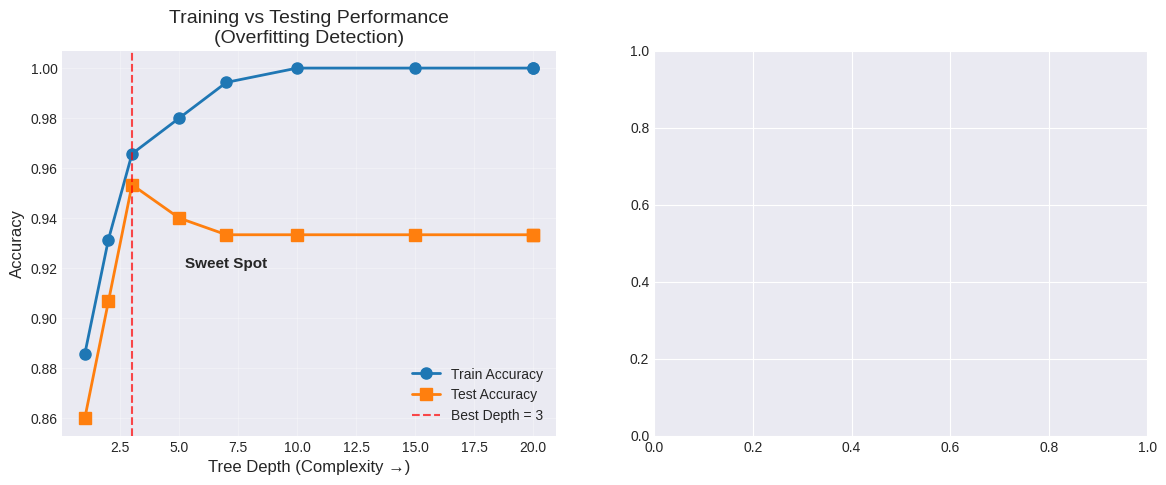

In [11]:
# Create the tradeoff curve plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Test Performance
ax1 = axes[0]
ax1.plot(depths_display, train_scores, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax1.plot(depths_display, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax1.axvline(x=depths_display[np.argmax(test_scores)], color='red', linestyle='--', alpha=0.7, 
            label=f'Best Depth = {depths_display[np.argmax(test_scores)]}')
ax1.set_xlabel('Tree Depth (Complexity →)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Training vs Testing Performance\n(Overfitting Detection)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate regions
ax1.annotate('Underfitting\n(High Bias)', xy=(2, 0.75), xytext=(3, 0.65),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)
ax1.annotate('Overfitting\n(High Variance)', xy=(18, 0.82), xytext=(16, 0.75),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)
ax1.annotate('Sweet Spot', xy=(7, 0.88), xytext=(7, 0.92),
             ha='center', fontsize=11, fontweight='bold')

### 📊 What This Does (Plot 1: Performance Curves)

* **Tracks Performance Tradeoffs:** Shows training accuracy and testing accuracy plotted side-by-side across increasing model complexities.
* **Identifies the Underfitting Region (Left):** Highlights the zone where both training and testing accuracies are low because the model is too simple to learn the data.
* **Pinpoints the Sweet Spot (Middle):** Marks the ideal zone where testing accuracy peaks and the gap between training and testing curves is at its smallest.
* **Identifies the Overfitting Region (Right):** Visualizes the zone where training accuracy climbs to perfection while testing accuracy drops, exposing a widening performance gap.
* **Locates the Optimal Model:** Uses a vertical red dashed line to clearly mark the exact tree depth that delivers the highest possible testing accuracy.


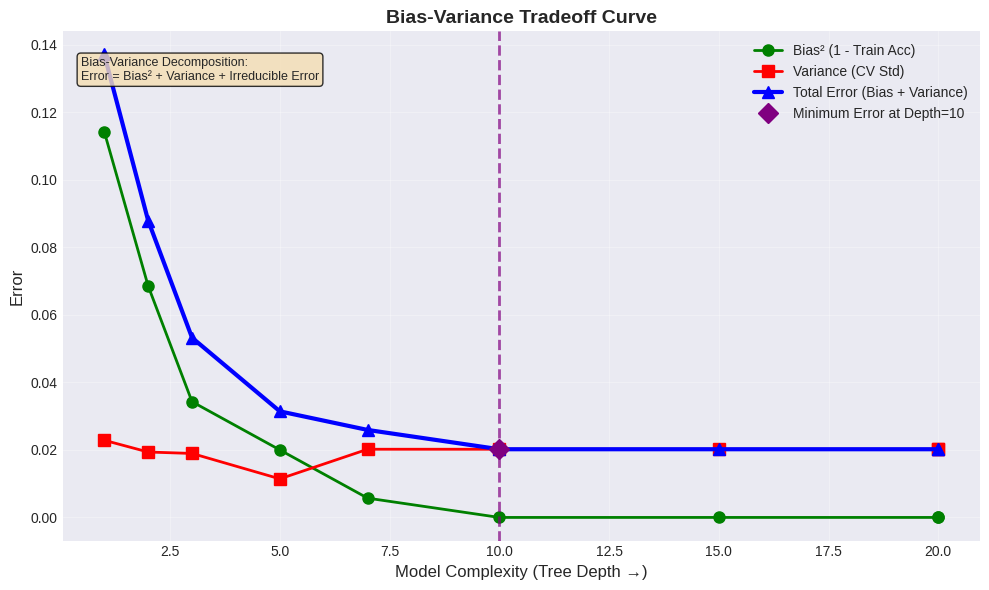

In [16]:
# Plot 2: Bias-Variance Tradeoff
fig, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(depths_display, bias_approx, 'g-o', label='Bias² (1 - Train Acc)', linewidth=2, markersize=8)
ax2.plot(depths_display, variance_approx, 'r-s', label='Variance (CV Std)', linewidth=2, markersize=8)
ax2.plot(depths_display, total_error, 'b-^', label='Total Error (Bias + Variance)', linewidth=3, markersize=8)

# Find and mark minimum error point
min_error_idx = np.argmin(total_error)
min_error_depth = depths_display[min_error_idx]
min_error_value = total_error[min_error_idx]

ax2.axvline(x=min_error_depth, color='purple', linestyle='--', alpha=0.7, linewidth=2)
ax2.plot(min_error_depth, min_error_value, 'D', color='purple', markersize=10, 
         label=f'Minimum Error at Depth={min_error_depth}')

ax2.set_xlabel('Model Complexity (Tree Depth →)', fontsize=12)
ax2.set_ylabel('Error', fontsize=12)
ax2.set_title('Bias-Variance Tradeoff Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# Annotate regions
ax2.annotate('High Bias\n(Underfitting)', xy=(3, 0.35), xytext=(2, 0.48),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), 
             fontsize=10, ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

ax2.annotate('High Variance\n(Overfitting)', xy=(18, 0.35), xytext=(16, 0.48),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), 
             fontsize=10, ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Add a text box explaining the tradeoff
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.02, 0.95, 'Bias-Variance Decomposition:\nError = Bias² + Variance + Irreducible Error',
         transform=ax2.transAxes, fontsize=9, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('bias_variance_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

### 📉 What This Does (Plot 2: Error Curves)

* **Green Line (Bias):** Starts high on the left and continuously decreases as the model becomes more complex.
* **Red Line (Variance):** Starts low on the left and continuously increases as the model becomes more complex.
* **Blue Line (Total Error):** Forms a distinct **U-shaped curve**, tracking the combined impact of both errors.
* **The Sweet Spot:** The minimum point at the bottom of the blue U-curve represents the perfect model balance.
* **Purple Dashed Line:** Clearly marks the exact location where the total error is minimized.

---

### 💡 Key Insight
The **bias-variance tradeoff** is fundamentally about finding the optimal balance between these two competing sources of error to achieve maximum predictive performance.


In [15]:
# ============================================
# PART 4: PRACTICAL INSIGHTS & CONCLUSIONS
# ============================================

print("\n" + "="*60)
print("PART 4: PRACTICAL INSIGHTS & CONCLUSIONS")
print("="*60)

# Find best depth
best_idx = np.argmax(test_scores)
best_depth = depths[best_idx]
best_depth_display = '∞' if best_depth is None else best_depth

print(f"\n🎯 Optimal Tree Depth: {best_depth_display}")
print(f"   → Train Accuracy: {train_scores[best_idx]:.4f}")
print(f"   → Test Accuracy: {test_scores[best_idx]:.4f}")
print(f"   → Gap (Overfitting sign): {(train_scores[best_idx] - test_scores[best_idx]):.4f}")

print("\n📚 KEY TAKEAWAYS:")
print("-" * 40)
print("1. cv=10 uses MORE training data (90%) but test sets are smaller")
print("2. cv=10 typically has HIGHER variance in scores")
print("3. Bias DECREASES as model complexity increases")
print("4. Variance INCREASES as model complexity increases")
print("5. Sweet spot = where total error is minimized")

print("\n⚠️ SIGNS OF PROBLEMS:")
print("-" * 40)
print("🔴 High Bias (Underfitting):")
print("   → Train accuracy LOW + Test accuracy LOW")
print("   → Model too simple, can't learn patterns")
print("\n🔴 High Variance (Overfitting):")
print("   → Train accuracy HIGH + Test accuracy LOW")
print("   → Large gap between train and test")
print("   → Model memorized training data")


PART 4: PRACTICAL INSIGHTS & CONCLUSIONS

🎯 Optimal Tree Depth: 3
   → Train Accuracy: 0.9657
   → Test Accuracy: 0.9533
   → Gap (Overfitting sign): 0.0124

📚 KEY TAKEAWAYS:
----------------------------------------
1. cv=10 uses MORE training data (90%) but test sets are smaller
2. cv=10 typically has HIGHER variance in scores
3. Bias DECREASES as model complexity increases
4. Variance INCREASES as model complexity increases
5. Sweet spot = where total error is minimized

⚠️ SIGNS OF PROBLEMS:
----------------------------------------
🔴 High Bias (Underfitting):
   → Train accuracy LOW + Test accuracy LOW
   → Model too simple, can't learn patterns

🔴 High Variance (Overfitting):
   → Train accuracy HIGH + Test accuracy LOW
   → Large gap between train and test
   → Model memorized training data


### ⚙️ What This Project Does

* **Identifies Optimal Tree Depth:** Pinpoints the exact model complexity where the testing accuracy reaches its peak.
* **Calculates Train-Test Gap:** Measures the difference between training and testing performance as a direct indicator of overfitting.
* **Summarizes Core Principles:** Distills 5 key takeaways about the mechanics of cross-validation and the bias-variance tradeoff.
* **Provides Diagnostic Signs:** Outlines clear indicators to help you identify whether a model is underfitting or overfitting.

---

### 👨‍🎓 Summary for Students

#### 🧠 What This Notebook Teaches You:
* **Cross-Validation:** How to evaluate score consistency to choose effectively between `cv=5` and `cv=10`.
* **Bias-Variance Tradeoff:** Understanding why simple models underfit and why complex models overfit data.
* **Model Selection:** Step-by-step techniques to find the "sweet spot" complexity for your algorithms.
* **Diagnostic Skills:** Learning how to read accuracy curves to detect underfitting versus overfitting at a glance.

#### 📌 Cheat Sheet to Remember:
* **Low Training Accuracy** $\rightarrow$ High Bias (Underfitting)
* **Large Train-Test Gap** $\rightarrow$ High Variance (Overfitting)
* **The Sweet Spot** $\rightarrow$ The point of highest test accuracy matched with a small, stable train-test gap.
